IMPORTING LIBRARIES

In [14]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    precision_recall_curve
)

import joblib
import os

In [7]:
os.chdir(r"C:\Users\nabee\OneDrive\Documents\GitHub\ML-Lab-Final-Group-3")
os.getcwd()

'C:\\Users\\nabee\\OneDrive\\Documents\\GitHub\\ML-Lab-Final-Group-3'

LOADING DATASET

In [19]:
d_dir = (r"C:\Users\nabee\OneDrive\Documents\GitHub\ML-Lab-Final-Group-3\data\processed")

#Load feature matrices
X_train = sp.load_npz(os.path.join(d_dir, "X_train_tfidf.npz"))
X_test = sp.load_npz(os.path.join(d_dir, "X_test_tfidf.npz"))
#Load target labels
y_train = pd.read_csv(os.path.join(d_dir, "y_train.csv"))["label"]
y_test = pd.read_csv(os.path.join(d_dir, "y_test.csv"))["label"]

CHECKING LABELS

In [23]:
print(y_train.head())
print(y_train.value_counts())

0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64
label
0    3613
1     522
Name: count, dtype: int64


In [24]:
print(y_test.head())
print(y_test.value_counts())
print(y_train.value_counts(normalize=True))

0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64
label
0    903
1    131
Name: count, dtype: int64
label
0    0.873761
1    0.126239
Name: proportion, dtype: float64


CHECKING DIMENSIONS

In [25]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4135, 3000)
X_test shape: (1034, 3000)
y_train shape: (4135,)
y_test shape: (1034,)


BASELINE MODEL

In [26]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
print("Baseline Accuracy:",
      accuracy_score(y_test, baseline_pred))
print("Baseline Precision:",
      precision_score(y_test, baseline_pred, zero_division=0))
print("Baseline Recall:",
      recall_score(y_test, baseline_pred, zero_division=0))
print("Baseline F1:",
      f1_score(y_test, baseline_pred, zero_division=0))

Baseline Accuracy: 0.8733075435203095
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


In [35]:
print("Actual test labels:")
print(y_test.value_counts())

print("\nBaseline predictions:")
print(pd.Series(baseline_pred).value_counts())

Actual test labels:
label
0    903
1    131
Name: count, dtype: int64

Baseline predictions:
0    1034
Name: count, dtype: int64


CANDIDATE MODEL1: LOGISTIC REGRESSION

In [27]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
print("Logistic Regression")
print("Accuracy:",
      accuracy_score(y_test, log_pred))
print("Precision:",
      precision_score(y_test, log_pred, zero_division=0))
print("Recall:",
      recall_score(y_test, log_pred, zero_division=0))
print("F1:",
      f1_score(y_test, log_pred, zero_division=0))

Logistic Regression
Accuracy: 0.9613152804642167
Precision: 0.9789473684210527
Recall: 0.7099236641221374
F1: 0.8230088495575221


In [42]:
#Spam Probability
log_prob = log_model.predict_proba(X_test)[:, 1]

CANDIDATE MODEL2: MULTINOMIAL NAIVE BAYES

In [28]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
print("Multinomial Naive Bayes")
print("Accuracy:",
      accuracy_score(y_test, nb_pred))
print("Precision:",
      precision_score(y_test, nb_pred, zero_division=0))
print("Recall:",
      recall_score(y_test, nb_pred, zero_division=0))
print("F1:",
      f1_score(y_test, nb_pred, zero_division=0))

Multinomial Naive Bayes
Accuracy: 0.9758220502901354
Precision: 1.0
Recall: 0.8091603053435115
F1: 0.8945147679324894


In [43]:
#Spam Probability
nb_prob = nb_model.predict_proba(X_test)[:, 1]

CANDIDATE MODEL3: LINEAR SVM

In [29]:
svm_model = LinearSVC(
    random_state=42
)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
print("Linear SVM")
print("Accuracy:",
      accuracy_score(y_test, svm_pred))
print("Precision:",
      precision_score(y_test, svm_pred, zero_division=0))
print("Recall:",
      recall_score(y_test, svm_pred, zero_division=0))
print("F1:",
      f1_score(y_test, svm_pred, zero_division=0))

Linear SVM
Accuracy: 0.9806576402321083
Precision: 0.9826086956521739
Recall: 0.8625954198473282
F1: 0.9186991869918699


In [45]:
svm_score = svm_model.decision_function(X_test)

CROSS-VALIDATION

In [30]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

CROSS-VALIDATION FOR MULTIPLE MODELS

In [31]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Multinomial Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(
        random_state=42
    )
}

In [32]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "pr_auc": "average_precision"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean()
    })

In [33]:
comparison = pd.DataFrame(cv_results)
print(comparison)

                     Model  Precision    Recall        F1    PR-AUC
0      Logistic Regression   0.983914  0.615055  0.755831  0.955114
1  Multinomial Naive Bayes   0.992793  0.800769  0.886265  0.966180
2               Linear SVM   0.982129  0.850696  0.911497  0.969546


In [34]:
os.makedirs("outputs", exist_ok=True)

comparison.to_csv(
    "outputs/model_comparison_cv.csv",
    index=False
)

HYPERPARAMETER TUNING

In [35]:
#LOGISTIC REGRESSION

from sklearn.model_selection import GridSearchCV
log_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)
log_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", log_grid.best_params_)
print("Best CV PR-AUC:", log_grid.best_score_)

Best Logistic Regression Parameters: {'C': 10}
Best CV PR-AUC: 0.9655200754244297


In [38]:
#MULTINOMIAL NAIVE BAYES

nb_param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1, 2]
}
nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)
nb_grid.fit(X_train, y_train)

print("Best Naive Bayes Parameters:", nb_grid.best_params_)
print("Best CV PR-AUC:", nb_grid.best_score_)

Best Naive Bayes Parameters: {'alpha': 0.1}
Best CV PR-AUC: 0.9712884082740849


In [39]:
#LINEAR SVM

svm_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}
svm_grid = GridSearchCV(
    LinearSVC(random_state=42),
    svm_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)
svm_grid.fit(X_train, y_train)

print("Best Linear SVM Parameters:", svm_grid.best_params_)
print("Best CV PR-AUC:", svm_grid.best_score_)

Best Linear SVM Parameters: {'C': 1}
Best CV PR-AUC: 0.9695455643767807


COMPARING TUNED MODELS

In [40]:
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],

    "CV PR-AUC": [
        log_grid.best_score_,
        nb_grid.best_score_,
        svm_grid.best_score_
    ]
})

print(tuned_results)

                     Model  CV PR-AUC
0      Logistic Regression   0.965520
1  Multinomial Naive Bayes   0.971288
2               Linear SVM   0.969546


SELECTING FINAL MODEL

In [42]:
final_model = nb_grid.best_estimator_

TESTING

In [43]:
final_model.fit(X_train, y_train)
test_pred = final_model.predict(X_test)

ACCURACY

In [44]:
accuracy = accuracy_score(
    y_test,
    test_pred
)
print("Accuracy:", accuracy)

Accuracy: 0.9816247582205029


SPAM PRECISION

In [77]:
precision = precision_score(
    y_test,
    test_pred,
    pos_label=1,
    zero_division=0
)
print("Spam Precision:", precision)

Spam Precision: 0.9590163934426229


RECALL

In [78]:
recall = recall_score(
    y_test,
    test_pred,
    pos_label=1,
    zero_division=0
)
print("Spam Recall:", recall)

Spam Recall: 0.8931297709923665


F1 SCORE

In [79]:
f1 = f1_score(
    y_test,
    test_pred,
    pos_label=1,
    zero_division=0
)
print("Spam F1:", f1)

Spam F1: 0.924901185770751


CONFUSION MATRIX

In [46]:
cm = confusion_matrix(
    y_test,
    test_pred
)
print(cm)

[[898   5]
 [ 14 117]]


In [47]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 898
False Positive: 5
False Negative: 14
True Positive : 117


CONFUSION MATRIX VISUALIZATION

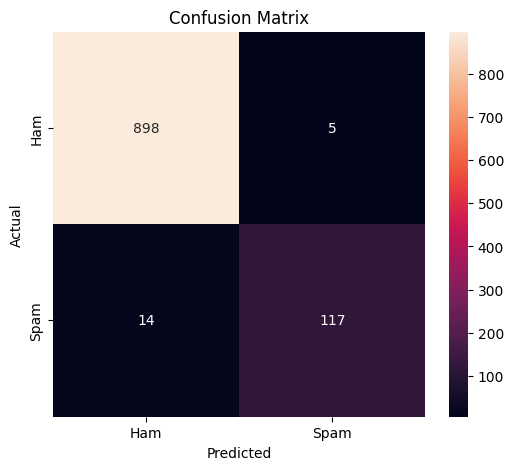

In [48]:
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CLASSIFICATION REPORT

In [49]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.96      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



PR-AUC

In [50]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_test_proba)
print("Naive Bayes Test PR-AUC:", pr_auc)

Naive Bayes Test PR-AUC: 0.9707888090227078


In [51]:
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

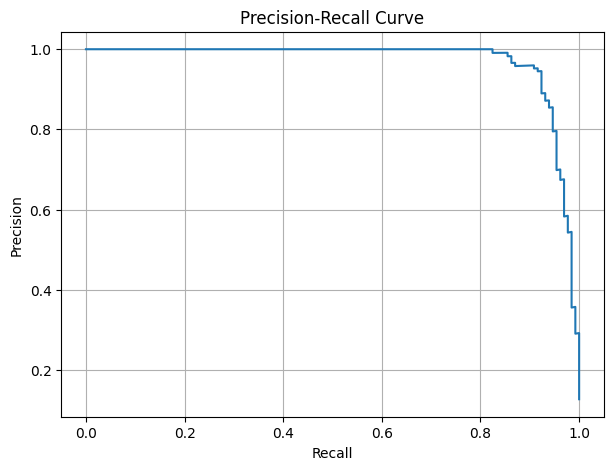

In [53]:
plt.figure(figsize=(7, 5))
plt.plot(
    recall_values,
    precision_values
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

ERROR ANALYSIS

In [54]:
test_clean = pd.read_csv(r"C:\Users\nabee\Downloads\test_clean.csv")
print(test_clean.head())

                                             message  label
0  good morning, my love ... i go to sleep now an...      0
1             and how you will do that, princess? :)      0
2            cool, i'll text you when i'm on the way      0
3   your right! i'll make the appointment right now.      0
4  aiya we discuss later lar... pick ü up at 4 is...      0


In [55]:
print(test_clean.columns)

Index(['message', 'label'], dtype='object')


In [56]:
errors = test_clean.copy()
errors["actual"] = y_test.values
errors["predicted"] = test_pred
errors["correct"] = (
    errors["actual"] == errors["predicted"]
)
errors["score"] = y_test_proba

In [59]:
misclassified = errors[
    errors["correct"] == False
]
print(misclassified.head(20))

                                               message  label  actual  \
79   thanks for the vote. now sing along with the s...      1       1   
168  hi if ur lookin 4 saucy daytime fun wiv busty ...      1       1   
230  asked 3mobile if 0870 chatlines inclu in free ...      1       1   
293                   are you free now?can i call now?      0       0   
308  hi its lucy hubby at meetins all day fri & i w...      1       1   
326  missed call alert. these numbers called but le...      1       1   
327                            k k:) sms chat with me.      0       0   
329  sms. ac sun0819 posts hello:"you seem cool, wa...      1       1   
437  babe: u want me dont u baby! im nasty and have...      1       1   
456  check out choose your babe videos @ sms.shsex....      1       1   
468                  88066 from 88066 lost 3pound help      1       1   
486  in the simpsons movie released in july 2007 na...      1       1   
494                 received, understood n acted up

FALSE POSITIVE

In [58]:
false_positives = errors[
    (errors["actual"] == 0) &
    (errors["predicted"] == 1)
]
print(false_positives)

                                     message  label  actual  predicted  \
293         are you free now?can i call now?      0       0          1   
327                  k k:) sms chat with me.      0       0          1   
494       received, understood n acted upon!      0       0          1   
689        unlimited texts. limited minutes.      0       0          1   
737  have you laid your airtel line to rest?      0       0          1   

     correct     score  
293    False  0.526718  
327    False  0.695028  
494    False  0.853169  
689    False  0.638636  
737    False  0.675561  


FALSE NEGATIVE

In [61]:
false_negatives = errors[
    (errors["actual"] == 1) &
    (errors["predicted"] == 0)
]
print(false_negatives)

                                               message  label  actual  \
79   thanks for the vote. now sing along with the s...      1       1   
168  hi if ur lookin 4 saucy daytime fun wiv busty ...      1       1   
230  asked 3mobile if 0870 chatlines inclu in free ...      1       1   
308  hi its lucy hubby at meetins all day fri & i w...      1       1   
326  missed call alert. these numbers called but le...      1       1   
329  sms. ac sun0819 posts hello:"you seem cool, wa...      1       1   
437  babe: u want me dont u baby! im nasty and have...      1       1   
456  check out choose your babe videos @ sms.shsex....      1       1   
468                  88066 from 88066 lost 3pound help      1       1   
486  in the simpsons movie released in july 2007 na...      1       1   
539  ever thought about living a good life with a p...      1       1   
544  xmas & new years eve tickets are now on sale f...      1       1   
690  latest news! police station toilet stolen, cop

SAVING THE FINAL MODEL

In [62]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    final_model,
    "models/spam_classifier.pkl"
)

['models/spam_classifier.pkl']

TESTING THE SAVED MODEL

In [63]:
loaded_model = joblib.load(
    "models/spam_classifier.pkl"
)

In [64]:
reloaded_pred = loaded_model.predict(X_test)

print(
    "Reloaded model accuracy:",
    accuracy_score(y_test, reloaded_pred)
)

Reloaded model accuracy: 0.9816247582205029


FINAL RESULTS

In [66]:
final_results = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Spam Precision": precision_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "Spam Recall": recall_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "Spam F1": f1_score(
        y_test,
        test_pred,
        zero_division=0
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_test_proba
    )
}

final_results_df = pd.DataFrame(
    [final_results]
)

print(final_results_df)

   Accuracy  Spam Precision  Spam Recall   Spam F1    PR-AUC
0  0.981625        0.959016      0.89313  0.924901  0.970789


VERIFYING SAVED MODEL

In [67]:
print(
    "Predictions match:",
    np.array_equal(test_pred, reloaded_pred)
)

Predictions match: True


SAVING FINAL RESULTS

In [68]:
os.makedirs("outputs", exist_ok=True)

final_results_df.to_csv(
    "outputs/final_model_results.csv",
    index=False
)